# Importations

In [1]:
# Numerical and scientific python programming
import numpy as np

import matplotlib.pyplot as plt

# Auxiliary python functions
from typing import Sequence

# Local importations
from moments.bloch import (generate_pauli_basis, compute_tensor_basis, compute_subset_index_map,
                           compute_bloch_norms_from_dm)
from moments.quantum import generate_GHZ_state, generate_W_state, compute_tensor_product, compute_outer_product

# Definitions

In [2]:
def rand_IO(d: int) -> np.ndarray:
    rng = np.random.default_rng()
    while True:
        mat = rng.normal(size=(d, d)) + 1j * rng.normal(size=(d, d))
        if np.linalg.matrix_rank(mat) == d:
            return mat

def rand_LIO(dims: Sequence[int]) -> np.ndarray:
    ops = [rand_IO(d) for d in dims]
    return compute_tensor_product(ops)

# Classes

In [3]:
Cl = ['Sep', 'Bi_12', 'Bi_13', 'Bi_23', 'W', 'GHZ']

C = len(Cl)

print('\nClasses:\n')

for c in Cl:

    print(c)

print('\nNumber of classes: ', C)


Classes:

Sep
Bi_12
Bi_13
Bi_23
W
GHZ

Number of classes:  6


# Random dataset generation

In [4]:
dn, N = 2, 3

dim = [dn] * N
d = int(np.prod(dim))

phi_0 = np.array([[1], [0]])
phi_1 = np.array([[0], [1]])

E_c = 100

RHO = {}

for c in Cl:
    
    rho = np.zeros((E_c, d, d), dtype = np.complex128)

    for e in range(E_c):
            
        if c == 'Sep':
            psi_e = compute_tensor_product(N * [phi_0])
        
        elif c == 'Bi_12':
            psi_e = (1 / np.sqrt(2)) * (compute_tensor_product(N * [phi_0]) + compute_tensor_product([phi_1, phi_1, phi_0]))
        
        elif c == 'Bi_13':
            psi_e = (1 / np.sqrt(2)) * (compute_tensor_product(N * [phi_0]) + compute_tensor_product([phi_1, phi_0, phi_1]))
        
        elif c == 'Bi_23':
            psi_e = (1 / np.sqrt(2)) * (compute_tensor_product(N * [phi_0]) + compute_tensor_product([phi_0, phi_1, phi_1]))
        
        elif c == 'W':
            psi_e = generate_W_state(N)
        
        else:
            psi_e = generate_GHZ_state(N)
    
        psi_e = rand_LIO(dim) @ psi_e
        psi_e = psi_e / np.linalg.norm(psi_e)
        
        rho[e] = compute_outer_product(psi_e, psi_e)
    
    RHO[c] = rho

# Computing moments

In [5]:
pauli_basis = generate_pauli_basis()

local_bases = [pauli_basis.copy()] * N
local_basis_sizes = [len(basis) for basis in local_bases]

tensor_basis = compute_tensor_basis(local_bases)
subset_index_map = compute_subset_index_map(local_basis_sizes)

R = {subset: {} for subset in subset_index_map.keys()}

for c in Cl:
    for subset in subset_index_map.keys():
        R[subset][c] = []
    for e in range(E_c):
        R_e = compute_bloch_norms_from_dm(tensor_basis, subset_index_map, RHO[c][e])
        for subset in subset_index_map.keys():
            R[subset][c].append(R_e[subset])

# Plots

## One-body marginal moments

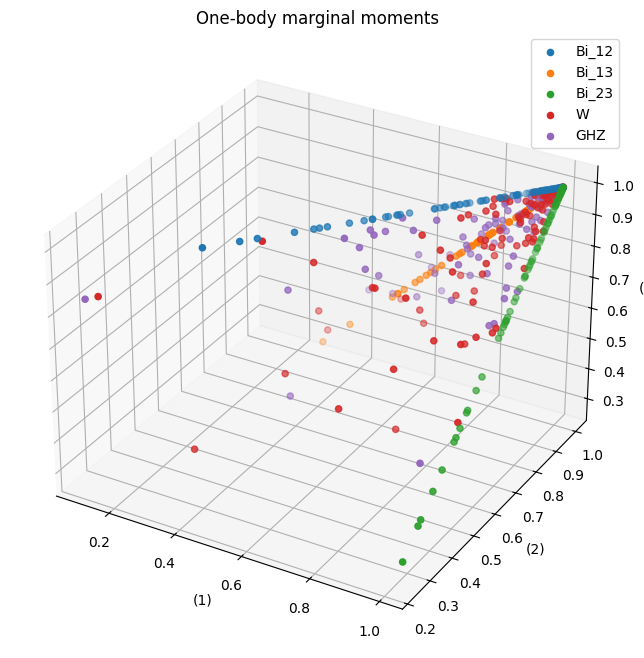

In [6]:
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(projection='3d')

ax.scatter(R[(1,)]['Bi_12'], R[(2,)]['Bi_12'], R[(3,)]['Bi_12'], label = 'Bi_12')
ax.scatter(R[(1,)]['Bi_13'], R[(2,)]['Bi_13'], R[(3,)]['Bi_13'], label = 'Bi_13')
ax.scatter(R[(1,)]['Bi_23'], R[(2,)]['Bi_23'], R[(3,)]['Bi_23'], label = 'Bi_23')
ax.scatter(R[(1,)]['W'], R[(2,)]['W'], R[(3,)]['W'], label = 'W')
ax.scatter(R[(1,)]['GHZ'], R[(2,)]['GHZ'], R[(3,)]['GHZ'], label = 'GHZ')

ax.set_xlabel('(1)')
ax.set_ylabel('(2)')
ax.set_zlabel('(3)')
ax.set_title('One-body marginal moments')

plt.legend()
plt.show()

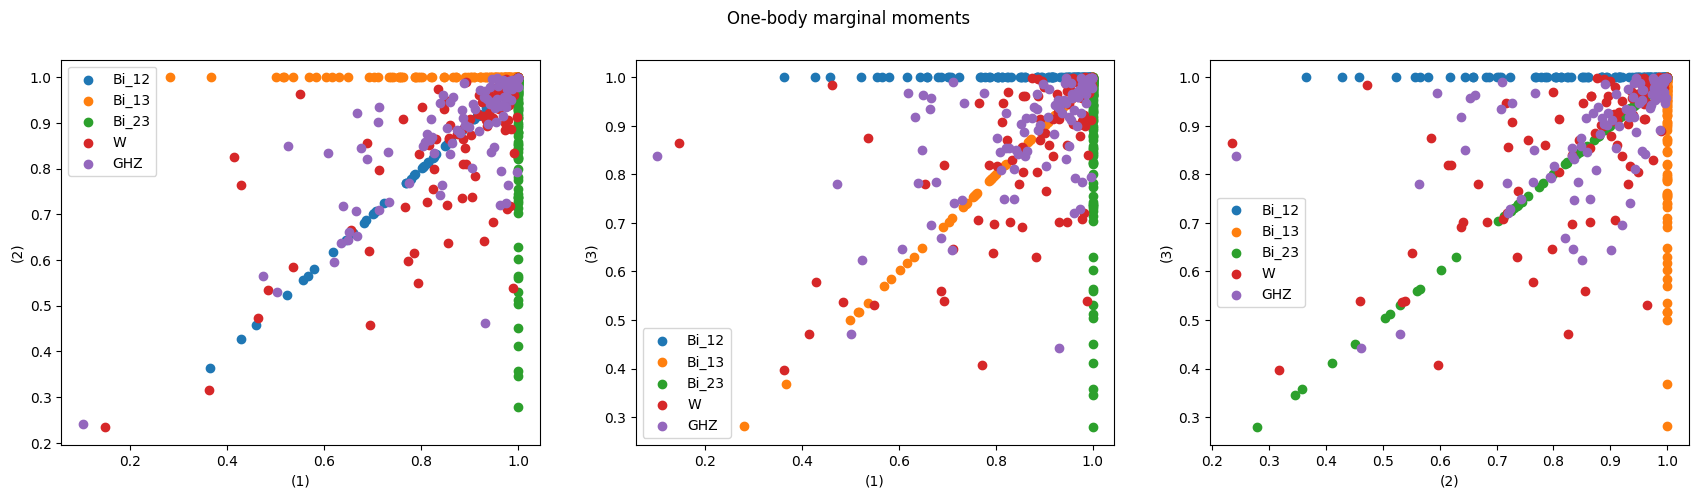

In [7]:
fig, ax = plt.subplots(1, 3, figsize=(21, 5))

ax[0].scatter(R[(1,)]['Bi_12'], R[(2,)]['Bi_12'], label = 'Bi_12')
ax[0].scatter(R[(1,)]['Bi_13'], R[(2,)]['Bi_13'], label = 'Bi_13')
ax[0].scatter(R[(1,)]['Bi_23'], R[(2,)]['Bi_23'], label = 'Bi_23')
ax[0].scatter(R[(1,)]['W'], R[(2,)]['W'], label = 'W')
ax[0].scatter(R[(1,)]['GHZ'], R[(2,)]['GHZ'], label = 'GHZ')

ax[1].scatter(R[(1,)]['Bi_12'], R[(3,)]['Bi_12'], label = 'Bi_12')
ax[1].scatter(R[(1,)]['Bi_13'], R[(3,)]['Bi_13'], label = 'Bi_13')
ax[1].scatter(R[(1,)]['Bi_23'], R[(3,)]['Bi_23'], label = 'Bi_23')
ax[1].scatter(R[(1,)]['W'], R[(3,)]['W'], label = 'W')
ax[1].scatter(R[(1,)]['GHZ'], R[(3,)]['GHZ'], label = 'GHZ')

ax[2].scatter(R[(2,)]['Bi_12'], R[(3,)]['Bi_12'], label = 'Bi_12')
ax[2].scatter(R[(2,)]['Bi_13'], R[(3,)]['Bi_13'], label = 'Bi_13')
ax[2].scatter(R[(2,)]['Bi_23'], R[(3,)]['Bi_23'], label = 'Bi_23')
ax[2].scatter(R[(2,)]['W'], R[(3,)]['W'], label = 'W')
ax[2].scatter(R[(2,)]['GHZ'], R[(3,)]['GHZ'], label = 'GHZ')

ax[0].set(xlabel = '(1)', ylabel = '(2)')
ax[1].set(xlabel = '(1)', ylabel = '(3)')
ax[2].set(xlabel = '(2)', ylabel = '(3)')

ax[0].legend()
ax[1].legend()
ax[2].legend()

fig.suptitle('One-body marginal moments')

plt.show()

## Two-body marginal moments

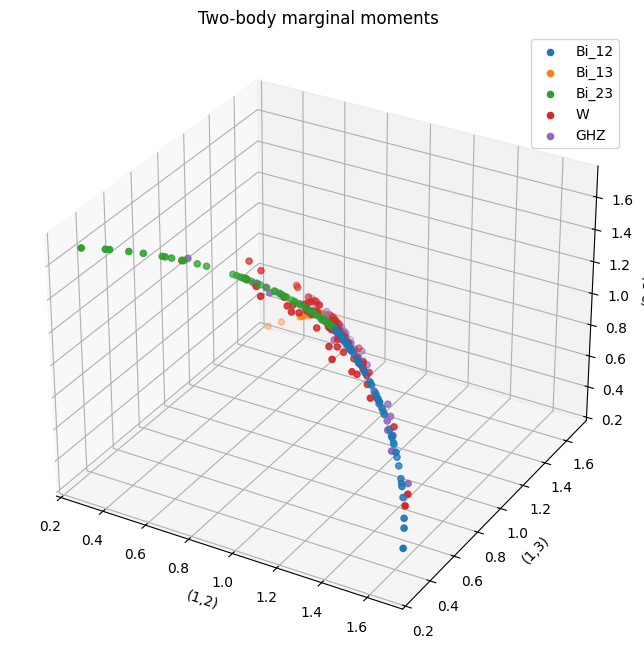

In [8]:
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(projection='3d')

ax.scatter(R[(1,2)]['Bi_12'], R[(1,3)]['Bi_12'], R[(2,3)]['Bi_12'], label = 'Bi_12')
ax.scatter(R[(1,2)]['Bi_13'], R[(1,3)]['Bi_13'], R[(2,3)]['Bi_13'], label = 'Bi_13')
ax.scatter(R[(1,2)]['Bi_23'], R[(1,3)]['Bi_23'], R[(2,3)]['Bi_23'], label = 'Bi_23')
ax.scatter(R[(1,2)]['W'], R[(1,3)]['W'], R[(2,3)]['W'], label = 'W')
ax.scatter(R[(1,2)]['GHZ'], R[(1,3)]['GHZ'], R[(2,3)]['GHZ'], label = 'GHZ')

ax.set_xlabel('(1,2)')
ax.set_ylabel('(1,3)')
ax.set_zlabel('(2,3)')
ax.set_title('Two-body marginal moments')

plt.legend()
plt.show()

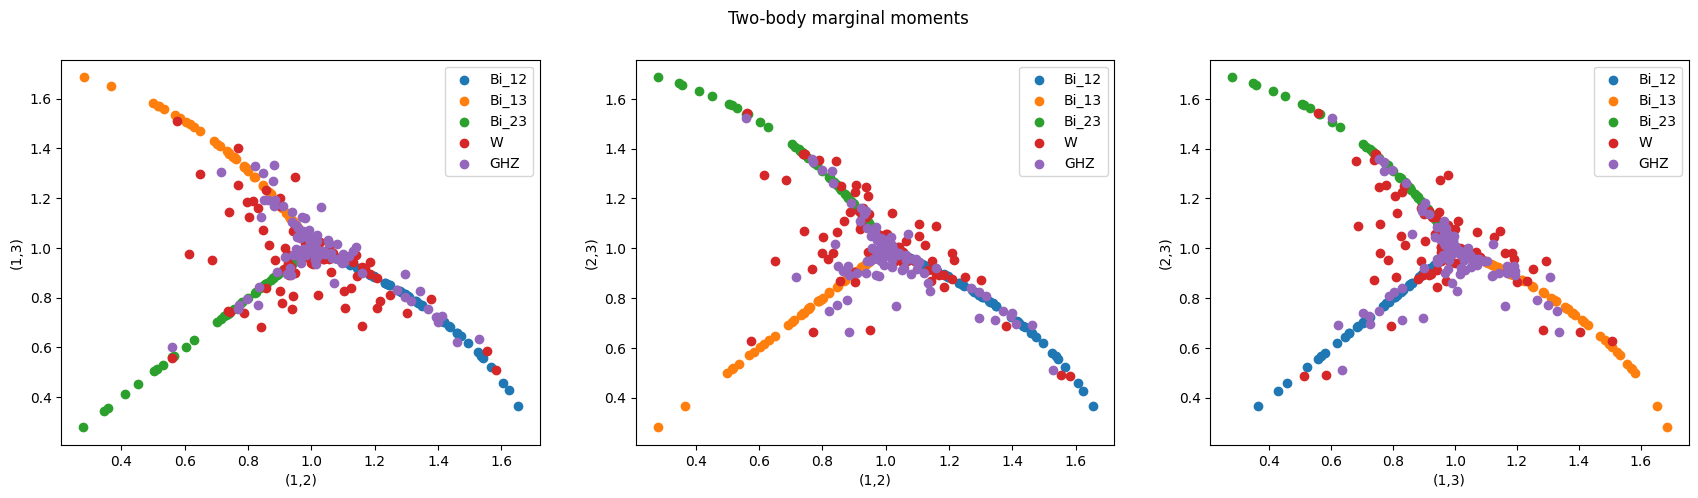

In [9]:
fig, ax = plt.subplots(1, 3, figsize=(21, 5))

ax[0].scatter(R[(1,2)]['Bi_12'], R[(1,3)]['Bi_12'], label = 'Bi_12')
ax[0].scatter(R[(1,2)]['Bi_13'], R[(1,3)]['Bi_13'], label = 'Bi_13')
ax[0].scatter(R[(1,2)]['Bi_23'], R[(1,3)]['Bi_23'], label = 'Bi_23')
ax[0].scatter(R[(1,2)]['W'], R[(1,3)]['W'], label = 'W')
ax[0].scatter(R[(1,2)]['GHZ'], R[(1,3)]['GHZ'], label = 'GHZ')

ax[1].scatter(R[(1,2)]['Bi_12'], R[(2,3)]['Bi_12'], label = 'Bi_12')
ax[1].scatter(R[(1,2)]['Bi_13'], R[(2,3)]['Bi_13'], label = 'Bi_13')
ax[1].scatter(R[(1,2)]['Bi_23'], R[(2,3)]['Bi_23'], label = 'Bi_23')
ax[1].scatter(R[(1,2)]['W'], R[(2,3)]['W'], label = 'W')
ax[1].scatter(R[(1,2)]['GHZ'], R[(2,3)]['GHZ'], label = 'GHZ')

ax[2].scatter(R[(1,3)]['Bi_12'], R[(2,3)]['Bi_12'], label = 'Bi_12')
ax[2].scatter(R[(1,3)]['Bi_13'], R[(2,3)]['Bi_13'], label = 'Bi_13')
ax[2].scatter(R[(1,3)]['Bi_23'], R[(2,3)]['Bi_23'], label = 'Bi_23')
ax[2].scatter(R[(1,3)]['W'], R[(2,3)]['W'], label = 'W')
ax[2].scatter(R[(1,3)]['GHZ'], R[(2,3)]['GHZ'], label = 'GHZ')

ax[0].set(xlabel = '(1,2)', ylabel = '(1,3)')
ax[1].set(xlabel = '(1,2)', ylabel = '(2,3)')
ax[2].set(xlabel = '(1,3)', ylabel = '(2,3)')

ax[0].legend()
ax[1].legend()
ax[2].legend()

fig.suptitle('Two-body marginal moments')

plt.show()